In [2]:
import numpy as np 
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

In [3]:
R_data = pd.read_csv("Health_data.csv")
R_data = R_data.loc[:, ~R_data.columns.str.match("Unnamed")]
R_data[0:15]

,AGE,VACCINATION,LIVER,GFR,IMMUNOGLOBULIN,SPIROMETRY,T_CELL_COUNT,Recovery_Status
0,56,YES,Normal,Normal,Normal,Normal,Normal,Recovered
1,69,YES,Normal,Abnormal,Normal,Normal,Abnormal,Slight_Risk
2,46,NO,Abnormal,Normal,Abnormal,Normal,Abnormal,Slight_Risk
3,32,NO,Normal,Normal,Abnormal,Normal,Normal,Slight_Risk
4,60,YES,Normal,Normal,Abnormal,Normal,Normal,Recovered
5,25,YES,Normal,Abnormal,Abnormal,Normal,Normal,Recovered
6,78,YES,Normal,Normal,Normal,Normal,Normal,Slight_Risk
7,38,NO,Abnormal,Normal,Normal,Abnormal,Normal,Slight_Risk
8,56,NO,Normal,Normal,Normal,Normal,Normal,Severe_Risk
9,75,YES,Abnormal,Normal,Normal,Normal,Normal,Recovered


In [4]:
print(len(R_data[R_data["LIVER"]=="Abnormal"]))
print(len(R_data[R_data["GFR"]=="Abnormal"]))
print(len(R_data[R_data["IMMUNOGLOBULIN"]=="Abnormal"]))
print(len(R_data[R_data["SPIROMETRY"]=="Abnormal"]))
print(len(R_data[R_data["T_CELL_COUNT"]=="Low"]))
print(len(R_data[R_data["AGE"]>=60]))
print(len(R_data[R_data["VACCINATION"]=="NO"]))
print(len(R_data[R_data["Recovery_Status"]=="Recovered"]))
print(len(R_data[R_data["Recovery_Status"]=="Slight_Risk"]))
print(len(R_data[R_data["Recovery_Status"]=="Mild_Risk"]))
print(len(R_data[R_data["Recovery_Status"]=="Severe_Risk"]))

126
201
205
125
0
353
291
723
123
119
35


In [5]:
len(R_data[R_data["AGE"]>40])

673

In [6]:
X = R_data[['AGE','VACCINATION','LIVER','GFR','IMMUNOGLOBULIN','SPIROMETRY','T_CELL_COUNT']].values


X[0:5]

array([[56, 'YES', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal'],
       [69, 'YES', 'Normal', 'Abnormal', 'Normal', 'Normal', 'Abnormal'],
       [46, 'NO', 'Abnormal', 'Normal', 'Abnormal', 'Normal', 'Abnormal'],
       [32, 'NO', 'Normal', 'Normal', 'Abnormal', 'Normal', 'Normal'],
       [60, 'YES', 'Normal', 'Normal', 'Abnormal', 'Normal', 'Normal']],
      dtype=object)

In [7]:
from sklearn import preprocessing
le_Vacc = preprocessing.LabelEncoder()
le_Vacc.fit(['YES','NO'])
X[:,1] = le_Vacc.transform(X[:,1]) 

le_L = preprocessing.LabelEncoder()
le_L.fit([ 'Normal', 'Abnormal'])
X[:,2] = le_L.transform(X[:,2])
le_G = preprocessing.LabelEncoder()
le_G.fit([ 'Normal', 'Abnormal'])
X[:,3] = le_G.transform(X[:,3])
le_I = preprocessing.LabelEncoder()
le_I.fit([ 'Normal', 'Abnormal'])
X[:,4] = le_I.transform(X[:,4])
le_S = preprocessing.LabelEncoder()
le_S.fit([ 'Normal', 'Abnormal'])
X[:,5] = le_S.transform(X[:,5])
le_T = preprocessing.LabelEncoder()
le_T.fit(['Normal', 'Abnormal'])
X[:,6] = le_T.transform(X[:,6])
X[0:5]


array([[56, 1, 1, 1, 1, 1, 1],
       [69, 1, 1, 0, 1, 1, 0],
       [46, 0, 0, 1, 0, 1, 0],
       [32, 0, 1, 1, 0, 1, 1],
       [60, 1, 1, 1, 0, 1, 1]], dtype=object)

In [8]:
Y = R_data["Recovery_Status"]
Y[0:10]


0      Recovered
1    Slight_Risk
2    Slight_Risk
3    Slight_Risk
4      Recovered
5      Recovered
6    Slight_Risk
7    Slight_Risk
8    Severe_Risk
9      Recovered
Name: Recovery_Status, dtype: object

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_trainset, X_testset, Y_trainset, Y_testset = train_test_split(X, Y, test_size=0.3, random_state=3)

In [11]:
print(f"Shape of X training set:{X_trainset.shape} & Size of Y training set:{Y_trainset.shape}")

Shape of X training set:(700, 7) & Size of Y training set:(700,)


In [12]:
print(f"Shape of X testing set:{X_testset.shape} & Size of Y testing set:{Y_testset.shape}")

Shape of X testing set:(300, 7) & Size of Y testing set:(300,)


In [13]:
RTree = DecisionTreeClassifier(criterion="gini", max_depth = 5)

In [14]:
RTree.fit(X_trainset,Y_trainset)

DecisionTreeClassifier(max_depth=5)

In [15]:
predTree = RTree.predict(X_testset)

In [16]:
print (predTree [:])
print (Y_testset [:])


['Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Slight_Risk' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Mild_Risk' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Severe_Risk' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Slight_Risk'
 'Recovered' 'Mild_Risk' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered' 'Recovered'
 'Recovered' 'Recovered' 'Recovered' 'Recover

In [17]:
df=pd.DataFrame(Y_testset)
print(df[df["Recovery_Status"]=="Recovered"].count())
print(len(df[df["Recovery_Status"]=="Mild_Risk"]))
print(len(df[df["Recovery_Status"]=="Slight_Risk"]))
print(len(df[df["Recovery_Status"]=="Severe_Risk"]))

Recovery_Status    216
dtype: int64
32
38
14


In [18]:
dft=pd.DataFrame(Y_trainset)
dft

,Recovery_Status
926,Recovered
411,Recovered
224,Recovered
14,Recovered
170,Recovered
...,...
952,Mild_Risk
643,Mild_Risk
249,Recovered
664,Recovered


In [19]:
X_testset

array([[20, 1, 1, ..., 1, 0, 1],
       [52, 0, 1, ..., 1, 1, 1],
       [45, 0, 1, ..., 1, 1, 1],
       ...,
       [56, 0, 1, ..., 0, 1, 1],
       [32, 0, 1, ..., 1, 1, 1],
       [31, 1, 1, ..., 0, 1, 1]], dtype=object)

In [20]:
df1=pd.DataFrame(X_testset,columns=['AGE','VACCINATION','LIVER','GFR','IMMUNOGLOBULIN','SPIROMETRY','T_CELL_COUNT'])
len(df1[df1['AGE']<=40])

100

In [21]:
from sklearn import metrics
import matplotlib.pyplot as plt
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(Y_testset, predTree))

DecisionTrees's Accuracy:  0.6933333333333334


In [22]:
from  io import StringIO
import pydotplus
import matplotlib.image as mpimg
from sklearn import tree
%matplotlib inline 

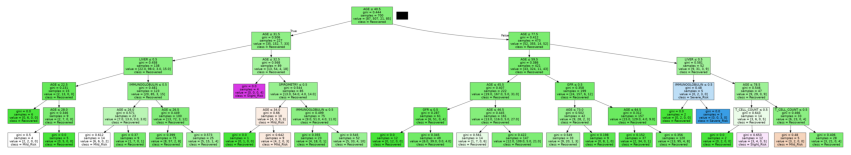

In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from io import StringIO
from sklearn import tree
import pydotplus
import numpy as np

# Assuming RTree is your trained DecisionTreeClassifier and R_data is your dataset

dot_data = StringIO()
filename = "Rtree.png"
featureNames = R_data.columns[0:7]

out = tree.export_graphviz(
    RTree,
    feature_names=featureNames,
    out_file=dot_data,
    class_names=np.unique(Y_trainset),
    filled=True,
    special_characters=True,
    rotate=False
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png(filename)

# Display the image
img = mpimg.imread(filename)
plt.figure(figsize=(15, 20))  # Reduced size
plt.imshow(img)
plt.axis('off')
plt.show()


In [24]:
RTree.predict([ [28,1, 0, 0, 0, 0, 0]])

array(['Mild_Risk'], dtype=object)

In [25]:
train_accuracy = []
validation_accuracy = []
for depth in range(1,10):
    dt_model = DecisionTreeClassifier(criterion='gini',max_depth=depth, random_state=3)
    dt_model.fit(X_trainset, Y_trainset)
    train_accuracy.append(dt_model.score(X_trainset, Y_trainset))
    validation_accuracy.append(dt_model.score(X_testset, Y_testset))

In [26]:
frame = pd.DataFrame({'max_depth':range(1,10), 'train_acc':train_accuracy, 'valid_acc':validation_accuracy})
frame.head()

,max_depth,train_acc,valid_acc
0,1,0.724286,0.720000
1,2,0.724286,0.720000
2,3,0.731429,0.716667
3,4,0.735714,0.720000
4,5,0.740000,0.693333


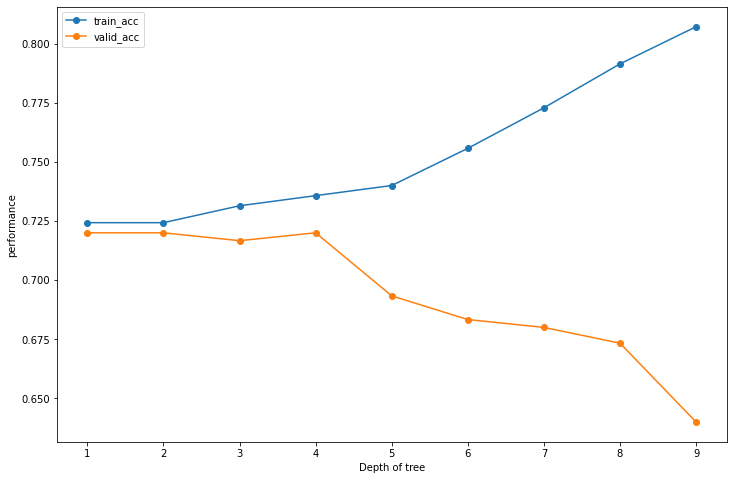

In [27]:
plt.figure(figsize=(12,8))
plt.plot(frame['max_depth'], frame['train_acc'], marker='o')
plt.plot(frame['max_depth'], frame['valid_acc'], marker='o')
plt.xlabel('Depth of tree')
plt.ylabel('performance')
plt.legend(['train_acc', 'valid_acc'])

In [28]:
df1=pd.DataFrame(X_testset,columns=['AGE','VACCINATION','LIVER','GFR','IMMUNOGLOBULIN','SPIROMETRY','T_CELL_COUNT'])


In [29]:
print(len(df1[df1['AGE']>40]))
print(len(df1[df1['LIVER']==0]))
print(len(df1[df1['GFR']==0]))
print(len(df1[df1['IMMUNOGLOBULIN']==0]))
print(len(df1[df1['SPIROMETRY']==0]))
print(len(df1[df1['T_CELL_COUNT']==0]))
print(len(df1[df1['VACCINATION']==0]))

200
37
63
66
37
44
83


In [30]:
df2=pd.DataFrame(X_trainset,columns=['AGE','VACCINATION','LIVER','GFR','IMMUNOGLOBULIN','SPIROMETRY','T_CELL_COUNT'])


In [31]:
print(len(df2[df2['AGE']>40]))
print(len(df2[df2['LIVER']==0]))
print(len(df2[df2['GFR']==0]))
print(len(df2[df2['IMMUNOGLOBULIN']==0]))
print(len(df2[df2['SPIROMETRY']==0]))
print(len(df2[df2['T_CELL_COUNT']==0]))
print(len(df2[df2['VACCINATION']==0]))

473
89
138
139
88
105
208


In [32]:
df3=df1.append(df)

/tmp/ipykernel_42724/4160918979.py:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df3=df1.append(df)


In [33]:
df3

,AGE,VACCINATION,LIVER,GFR,IMMUNOGLOBULIN,SPIROMETRY,T_CELL_COUNT,Recovery_Status
0,20,1,1,1,1,0,1,NaN
1,52,0,1,1,1,1,1,NaN
2,45,0,1,1,1,1,1,NaN
3,56,1,1,1,0,1,0,NaN
4,62,1,1,0,1,1,1,NaN
...,...,...,...,...,...,...,...,...
466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Slight_Risk
654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Slight_Risk
279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Recovered
945,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Severe_Risk


In [38]:
df=df.reset_index(drop=True)
df1=df1.reset_index(drop=True)
d = pd.concat([df1, df], axis=1, join="inner")
d[0:15]

,AGE,VACCINATION,LIVER,GFR,IMMUNOGLOBULIN,SPIROMETRY,T_CELL_COUNT,Recovery_Status
0,20,1,1,1,1,0,1,Severe_Risk
1,52,0,1,1,1,1,1,Recovered
2,45,0,1,1,1,1,1,Slight_Risk
3,56,1,1,1,0,1,0,Mild_Risk
4,62,1,1,0,1,1,1,Slight_Risk
5,29,0,1,1,1,1,1,Recovered
6,45,1,1,1,1,1,1,Recovered
7,78,1,1,1,1,1,1,Recovered
8,71,1,1,0,1,1,1,Recovered
9,59,1,1,1,1,1,1,Recovered


In [46]:
df2=df2.reset_index(drop=True)
dft=dft.reset_index(drop=True)
d1 = pd.concat([df2, dft], axis=1, join="inner")

d1.shape




(700, 8)

In [47]:
print(len(d[d['AGE']>40]))
print(len(d[d['LIVER']==0]))
print(len(d[d['GFR']==0]))
print(len(d[d['IMMUNOGLOBULIN']==0]))
print(len(d[d['SPIROMETRY']==0]))
print(len(d[d['T_CELL_COUNT']==0]))
print(len(d[d['VACCINATION']==0]))

200
37
63
66
37
44
83


In [48]:

print(len(d[(d.LIVER==0) & (d.Recovery_Status=='Severe_Risk')]))
print(len(d[(d.GFR==0) & (d.Recovery_Status=='Severe_Risk')]))
print(len(d[(d.IMMUNOGLOBULIN==0) & (d.Recovery_Status=='Severe_Risk')]))
print(len(d[(d.SPIROMETRY==0) & (d.Recovery_Status=='Severe_Risk')]))
print(len(d[(d.T_CELL_COUNT==0) & (d.Recovery_Status=='Severe_Risk')]))
             

2
3
2
2
3


In [49]:
print(len(d[(d.LIVER==0) & (d.Recovery_Status=='Mild_Risk')]))
print(len(d[(d.GFR==0) & (d.Recovery_Status=='Mild_Risk')]))
print(len(d[(d.IMMUNOGLOBULIN==0) & (d.Recovery_Status=='Mild_Risk')]))
print(len(d[(d.SPIROMETRY==0) & (d.Recovery_Status=='Mild_Risk')]))
print(len(d[(d.T_CELL_COUNT==0) & (d.Recovery_Status=='Mild_Risk')]))
             

4
5
8
7
5


In [50]:
print(len(d[(d.LIVER==0) & (d.Recovery_Status=='Slight_Risk')]))
print(len(d[(d.GFR==0) & (d.Recovery_Status=='Slight_Risk')]))
print(len(d[(d.IMMUNOGLOBULIN==0) & (d.Recovery_Status=='Slight_Risk')]))
print(len(d[(d.SPIROMETRY==0) & (d.Recovery_Status=='Slight_Risk')]))
print(len(d[(d.T_CELL_COUNT==0) & (d.Recovery_Status=='Slight_Risk')]))

3
7
10
4
3


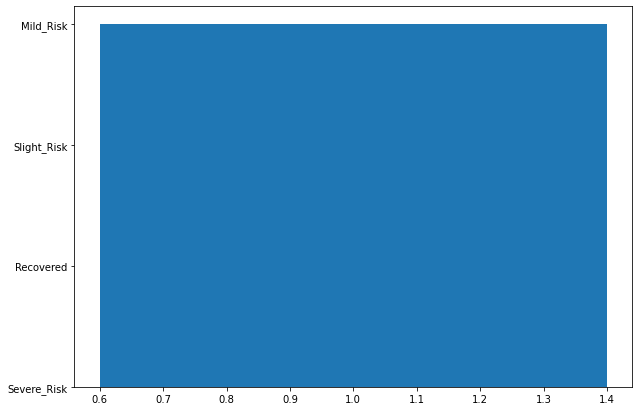

In [51]:
import pandas as pd
from matplotlib import pyplot as plt
 
name = d['LIVER'].head(32)
price = d['Recovery_Status'].head(32)
 
# Figure Size
fig = plt.figure(figsize =(10, 7))
 
# Horizontal Bar Plot
plt.bar(name[0:10], price[0:10])
 
# Show Plot
plt.show()

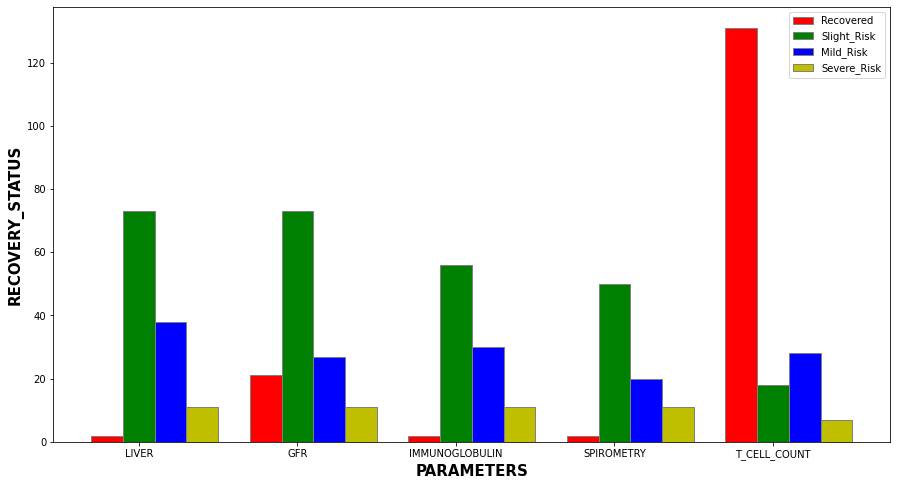

In [52]:
import numpy as np
import matplotlib.pyplot as plt
 
# set width of bar
barWidth = 0.20
fig = plt.subplots(figsize =(15, 8))
 
# set height of bar
Recovered = [2, 21, 2, 2, 131]
Slight_Risk = [73, 73, 56, 50, 18]
Mild_Risk = [38, 27, 30, 20, 28]
Severe_Risk = [11, 11, 11, 11, 7]
 
# Set position of bar on X axis
br1 = np.arange(len(Recovered))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
 
 
# Make the plot
plt.bar(br1, Recovered, color ='r', width = barWidth,
        edgecolor ='grey', label ='Recovered')
plt.bar(br2, Slight_Risk, color ='g', width = barWidth,
        edgecolor ='grey', label ='Slight_Risk')
plt.bar(br3, Mild_Risk, color ='b', width = barWidth,
        edgecolor ='grey', label ='Mild_Risk')
plt.bar(br4, Severe_Risk, color ='y', width = barWidth,
        edgecolor ='grey', label ='Severe_Risk')
 
# Adding Xticks
plt.xlabel('PARAMETERS', fontweight ='bold', fontsize = 15)
plt.ylabel('RECOVERY_STATUS', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(Recovered))],
        ['LIVER', 'GFR', 'IMMUNOGLOBULIN', 'SPIROMETRY', 'T_CELL_COUNT'])
 
plt.legend()
plt.show()

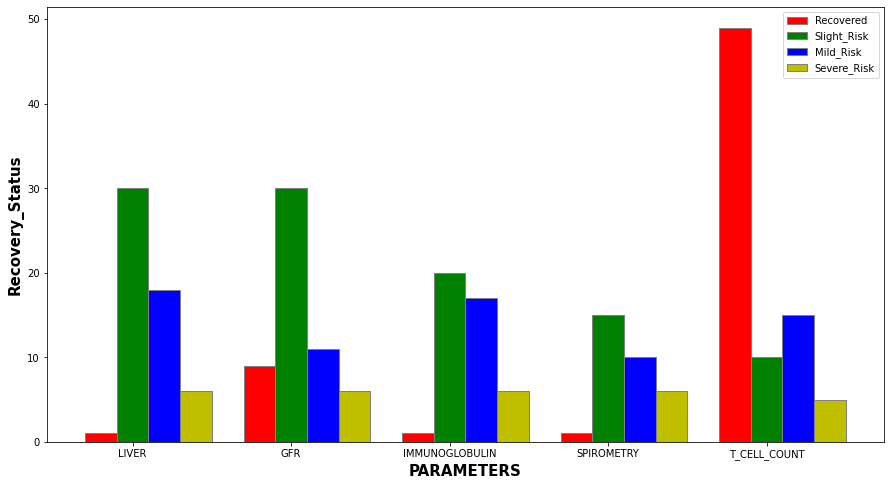

In [53]:
import numpy as np
import matplotlib.pyplot as plt
 
# set width of bar
barWidth = 0.20
fig = plt.subplots(figsize =(15, 8))
 
# set height of bar
Recovered = [1, 9, 1, 1, 49]
Slight_Risk = [30, 30, 20, 15, 10]
Mild_Risk = [18, 11, 17, 10, 15]
Severe_Risk = [6, 6, 6, 6, 5]
 
# Set position of bar on X axis
br1 = np.arange(len(Recovered))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
 
 
# Make the plot
plt.bar(br1, Recovered, color ='r', width = barWidth,
        edgecolor ='grey', label ='Recovered')
plt.bar(br2, Slight_Risk, color ='g', width = barWidth,
        edgecolor ='grey', label ='Slight_Risk')
plt.bar(br3, Mild_Risk, color ='b', width = barWidth,
        edgecolor ='grey', label ='Mild_Risk')
plt.bar(br4, Severe_Risk, color ='y', width = barWidth,
        edgecolor ='grey', label ='Severe_Risk')
 
# Adding Xticks
plt.xlabel('PARAMETERS', fontweight ='bold', fontsize = 15)
plt.ylabel('Recovery_Status', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(Recovered))],
        ['LIVER', 'GFR', 'IMMUNOGLOBULIN', 'SPIROMETRY', 'T_CELL_COUNT'])
 
plt.legend()
plt.show()

In [54]:
import joblib
joblib.dump(RTree, 'covid_recovery_model.pkl')


['covid_recovery_model.pkl']